# Task 6A: Simulated Super-Resolution (PI-HAF, End-to-End)

> Goal: run a config-driven PI-HAF pipeline from training to evaluation with reproducible metrics and publication-ready artifacts.

This notebook mirrors the quality standard used in Task 1: strong logging, fail-fast checks, modular engine usage, and final JSON reporting.

## Cell 1 - Setup, Logging, and CUDA Gate

 > This section configures deterministic behavior, public API imports, and runtime telemetry before any data/model operations.

In [1]:
from __future__ import annotations

import gc
import json
import logging
import os
from datetime import datetime
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from torch.utils.data import DataLoader

# Resolve repository root regardless of notebook execution location.
if (Path.cwd() / "src").exists():
    REPO_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    REPO_ROOT = Path.cwd().parent
else:
    raise RuntimeError("Could not locate repository root containing 'src' directory.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data_utils import Task6Dataset
from src.data_utils.transforms import get_augmentation_transforms
from src.engine import ReflowSampler, evaluate_super_resolution, train_sr_from_config
from src.models import PIHAFBackbone

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
LOGGER = logging.getLogger("task6a_notebook")

DEFAULT_SEED = 42
np.random.seed(DEFAULT_SEED)
torch.manual_seed(DEFAULT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(DEFAULT_SEED)

LOGGER.info("Repository root: %s", REPO_ROOT)
LOGGER.info("Torch version: %s", torch.__version__)
LOGGER.info("CUDA available: %s", torch.cuda.is_available())
if torch.cuda.is_available():
    LOGGER.info("CUDA device: %s", torch.cuda.get_device_name(0))

2026-03-30 17:13:54,190 | INFO | task6a_notebook | Repository root: /home/yash_gupta/ml4sci/ml4sci
2026-03-30 17:13:54,194 | INFO | task6a_notebook | Torch version: 2.5.1+cu121
2026-03-30 17:13:54,195 | INFO | task6a_notebook | CUDA available: True
2026-03-30 17:13:54,467 | INFO | task6a_notebook | CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU


## Cell 2 - Config and Data Loaders

 > Load config, enforce file-system validity, build deterministic train/val/test splits, and construct normalized dataloaders.

In [2]:
CONFIG_PATH = REPO_ROOT / "configs" / "task6a_simulated_sr.yaml"
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing config file: {CONFIG_PATH}")

with open(CONFIG_PATH, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

seed = int(config.get("seed", DEFAULT_SEED))
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

dataset_cfg = config.get("dataset", {})
split_cfg = dataset_cfg.get("split", {})
data_root = REPO_ROOT / dataset_cfg.get("data_root", "data/dataset_task6A")
lr_dir = data_root / "LR"
hr_dir = data_root / "HR"

if not lr_dir.exists() or not hr_dir.exists():
    raise FileNotFoundError(f"Missing Task6A dataset folders: {lr_dir} and/or {hr_dir}")

def _sample_id(path: Path) -> int:
    if not path.stem.startswith("sample"):
        raise ValueError(f"Unexpected file name format: {path.name}")
    return int(path.stem.replace("sample", ""))

lr_map = {_sample_id(path): path for path in lr_dir.glob("sample*.npy")}
hr_map = {_sample_id(path): path for path in hr_dir.glob("sample*.npy")}
paired_ids = sorted(set(lr_map.keys()) & set(hr_map.keys()))
if not paired_ids:
    raise RuntimeError("No paired LR/HR files found in dataset_task6A")

train_ratio = float(split_cfg.get("train", 0.7))
val_ratio = float(split_cfg.get("val", 0.15))
if train_ratio <= 0.0 or val_ratio < 0.0 or train_ratio + val_ratio >= 1.0:
    raise ValueError(f"Invalid split ratios: train={train_ratio}, val={val_ratio}")

n_total = len(paired_ids)
n_train = int(n_total * train_ratio)
n_val = int(n_total * val_ratio)
train_ids = paired_ids[:n_train]
val_ids = paired_ids[n_train : n_train + n_val]
test_ids = paired_ids[n_train + n_val :]

if len(train_ids) == 0 or len(test_ids) == 0:
    raise RuntimeError(
        f"Split resulted in empty train/test sets: train={len(train_ids)} test={len(test_ids)}"
    )

def _load_split(ids: list[int]):
    lr_data = [np.load(lr_map[idx]).astype(np.float32, copy=False) for idx in ids]
    hr_data = [np.load(hr_map[idx]).astype(np.float32, copy=False) for idx in ids]
    return lr_data, hr_data

lr_train, hr_train = _load_split(train_ids)
lr_val, hr_val = _load_split(val_ids)
lr_test, hr_test = _load_split(test_ids)

normalize_tf = get_augmentation_transforms(normalize=True)
train_dataset = Task6Dataset(lr_data=lr_train, hr_data=hr_train, transforms=normalize_tf)
val_dataset = Task6Dataset(lr_data=lr_val, hr_data=hr_val, transforms=normalize_tf)
test_dataset = Task6Dataset(lr_data=lr_test, hr_data=hr_test, transforms=normalize_tf)

batch_size = int(config.get("training", {}).get("batch_size", 16))
num_workers = int(config.get("training", {}).get("num_workers", 4))
pin_memory = bool(config.get("training", {}).get("pin_memory", True)) and torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

weights_dir = REPO_ROOT / "weights"
weights_dir.mkdir(parents=True, exist_ok=True)
checkpoint_name = "task6a_reflow_best.pth"
checkpoint_path = weights_dir / checkpoint_name

LOGGER.info("Loaded config: %s", CONFIG_PATH)
LOGGER.info("Seed: %d", seed)
LOGGER.info("Paired samples: total=%d train=%d val=%d test=%d", n_total, len(train_ids), len(val_ids), len(test_ids))
LOGGER.info("DataLoader: batch_size=%d num_workers=%d pin_memory=%s", batch_size, num_workers, pin_memory)

2026-03-30 17:14:12,746 | INFO | task6a_notebook | Loaded config: /home/yash_gupta/ml4sci/ml4sci/configs/task6a_simulated_sr.yaml
2026-03-30 17:14:12,752 | INFO | task6a_notebook | Seed: 42
2026-03-30 17:14:12,756 | INFO | task6a_notebook | Paired samples: total=10000 train=7000 val=1500 test=1500
2026-03-30 17:14:12,757 | INFO | task6a_notebook | DataLoader: batch_size=48 num_workers=4 pin_memory=True


## Cell 3 - Training Engine (PI-HAF)

 > Instantiate PI-HAF from config and train via modular engine API. Best checkpoint is saved as `weights/task6a_reflow_best.pth`.

In [3]:
model_cfg = dict(config.get("model", {}))
model_cfg.pop("architecture", None)
model = PIHAFBackbone(config=model_cfg)

device_str = str(config.get("device", "auto"))
configured_epochs = int(config.get("training", {}).get("num_epochs", 200))
requested_epochs = int(os.environ.get("TASK6A_NOTEBOOK_EPOCHS", str(configured_epochs)))
if requested_epochs <= 0:
    raise ValueError(f"TASK6A_NOTEBOOK_EPOCHS must be > 0, got {requested_epochs}")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

LOGGER.info("Starting Task6A training | epochs=%d | device=%s", requested_epochs, device_str)
model, history = train_sr_from_config(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    checkpoint_dir=str(weights_dir),
    checkpoint_name=checkpoint_name,
    device=device_str,
    num_epochs=requested_epochs,
)

train_peak_gib = None
if torch.cuda.is_available():
    train_peak_gib = torch.cuda.max_memory_allocated() / (1024 ** 3)

LOGGER.info("Training complete. Checkpoint: %s", checkpoint_path)
if train_peak_gib is not None:
    LOGGER.info("Training peak VRAM: %.3f GiB", train_peak_gib)

if history["val_total_loss"]:
    LOGGER.info("Final val_total_loss: %.6f", float(history["val_total_loss"][-1]))

2026-03-30 17:14:12,873 | INFO | task6a_notebook | Starting Task6A training | epochs=20 | device=cuda
2026-03-30 17:14:12,877 | INFO | src.engine.train_sr | Optimizer no-decay gate params: count=5 names=['skip_gates.0', 'skip_gates.1', 'cross_attention.1.gate', 'cross_attention.2.gate', 'cross_attention.3.gate']
2026-03-30 17:14:37,650 | INFO | src.engine.train_sr | Task6 reflow train step 10/146
2026-03-30 17:15:00,179 | INFO | src.engine.train_sr | Task6 reflow train step 20/146
2026-03-30 17:15:24,254 | INFO | src.engine.train_sr | Task6 reflow train step 30/146
2026-03-30 17:15:48,640 | INFO | src.engine.train_sr | Task6 reflow train step 40/146
2026-03-30 17:16:13,424 | INFO | src.engine.train_sr | Task6 reflow train step 50/146
2026-03-30 17:16:37,688 | INFO | src.engine.train_sr | Task6 reflow train step 60/146
2026-03-30 17:17:03,195 | INFO | src.engine.train_sr | Task6 reflow train step 70/146
2026-03-30 17:17:29,728 | INFO | src.engine.train_sr | Task6 reflow train step 80/14

## Cell 4 - VRAM Flush

 > Flush cached GPU memory and Python objects before evaluation to avoid cross-phase memory carryover.

In [4]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
LOGGER.info("VRAM flush complete (torch.cuda.empty_cache + gc.collect)")

2026-03-30 19:22:48,126 | INFO | task6a_notebook | VRAM flush complete (torch.cuda.empty_cache + gc.collect)


## Cell 5 - Evaluation Engine

 > Load best weights, run rectified-flow sampling on test data, and compute batched PSNR/SSIM with memory-safe aggregation.

In [5]:
device = torch.device(device_str if (device_str != "auto") else ("cuda" if torch.cuda.is_available() else "cpu"))
eval_model = PIHAFBackbone(config=model_cfg).to(device)

if not checkpoint_path.exists():
    raise FileNotFoundError(f"Expected trained checkpoint at: {checkpoint_path}")

checkpoint = torch.load(str(checkpoint_path), map_location=device)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    eval_model.load_state_dict(checkpoint["model_state_dict"], strict=True)
else:
    eval_model.load_state_dict(checkpoint, strict=True)

sampler_steps = int(config.get("sampler", {}).get("num_steps", 15))
sampler = ReflowSampler(model=eval_model, num_steps=sampler_steps, device=device)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

eval_results = evaluate_super_resolution(
    model=eval_model,
    sampler=sampler,
    test_loader=test_loader,
    device=device,
    flush_every_n_batches=25,
 )

eval_peak_gib = None
if torch.cuda.is_available():
    eval_peak_gib = torch.cuda.max_memory_allocated() / (1024 ** 3)

LOGGER.info("Evaluation complete on %d samples", int(eval_results["num_samples"]))
LOGGER.info("PSNR: %.4f dB", float(eval_results["psnr"]))
LOGGER.info("SSIM: %.6f", float(eval_results["ssim"]))
if eval_peak_gib is not None:
    LOGGER.info("Evaluation peak VRAM: %.3f GiB", eval_peak_gib)

/tmp/ipykernel_91010/2349539750.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(str(checkpoint_path), map_location=device)
2026-03-30 20:05:27,04

## Cell 6 - Publication Visuals

 > Render a clean 3x3 panel with inferno colormap: [Low-Res Input | AI Super-Res | Ground Truth HR].

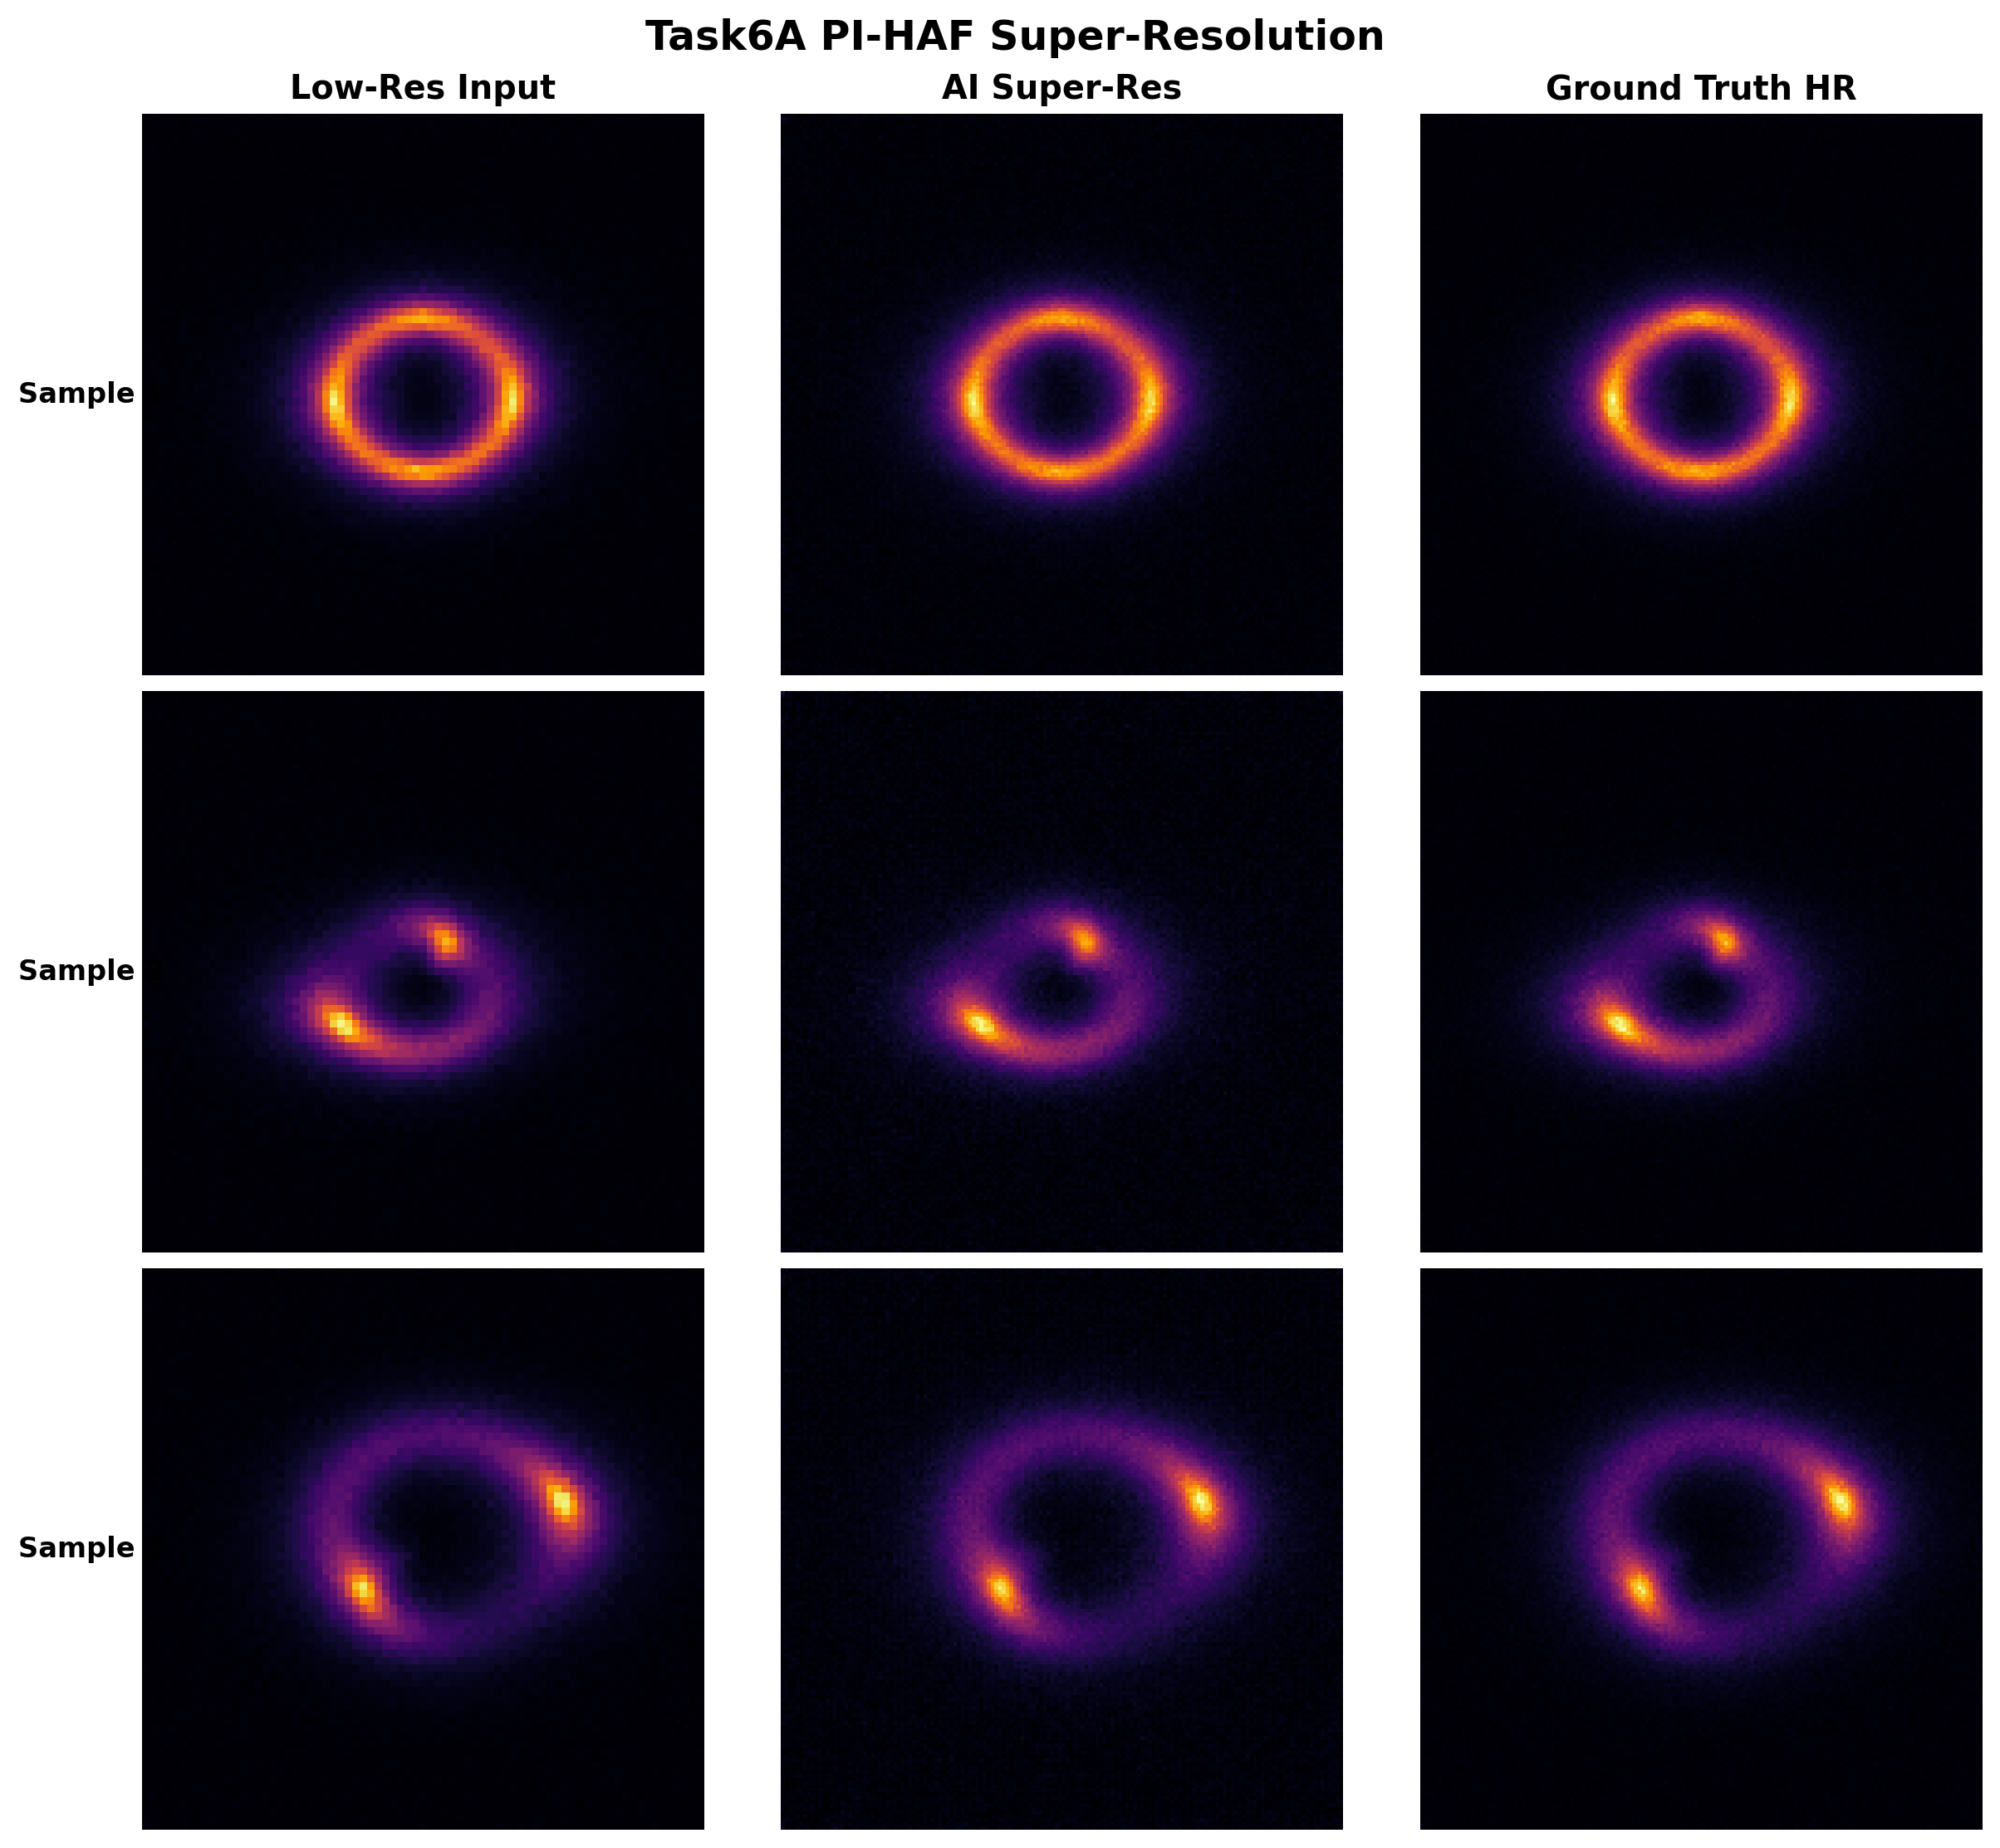

2026-03-30 20:06:52,415 | INFO | task6a_notebook | Saved visualization: /home/yash_gupta/ml4sci/ml4sci/outputs/task6/task6a_publication_grid.png


In [6]:
eval_model.eval()
with torch.no_grad():
    lr_batch_norm, hr_batch_norm = next(iter(test_loader))
    lr_batch_norm = lr_batch_norm.to(device, non_blocking=True)
    hr_batch_norm = hr_batch_norm.to(device, non_blocking=True)
    sr_batch_01 = sampler.sample(lr_batch_norm)

lr_batch_01 = torch.clamp((lr_batch_norm * 0.5) + 0.5, 0.0, 1.0).detach().cpu()
hr_batch_01 = torch.clamp((hr_batch_norm * 0.5) + 0.5, 0.0, 1.0).detach().cpu()
sr_batch_01 = torch.clamp(sr_batch_01, 0.0, 1.0).detach().cpu()

num_show = min(3, lr_batch_01.shape[0])
fig, axes = plt.subplots(3, 3, figsize=(11, 10), dpi=220, constrained_layout=True)

column_titles = ["Low-Res Input", "AI Super-Res", "Ground Truth HR"]
for col_idx, title in enumerate(column_titles):
    axes[0, col_idx].set_title(title, fontsize=13, fontweight="bold")

for row_idx in range(3):
    if row_idx < num_show:
        row_images = [
            lr_batch_01[row_idx, 0].numpy(),
            sr_batch_01[row_idx, 0].numpy(),
            hr_batch_01[row_idx, 0].numpy(),
        ]
    else:
        row_images = [
            np.zeros((75, 75), dtype=np.float32),
            np.zeros((150, 150), dtype=np.float32),
            np.zeros((150, 150), dtype=np.float32),
        ]

    for col_idx, image_2d in enumerate(row_images):
        ax = axes[row_idx, col_idx]
        ax.imshow(image_2d, cmap="inferno", vmin=0.0, vmax=1.0, interpolation="nearest")
        ax.axis("off")

    axes[row_idx, 0].text(
        -0.22,
        0.5,
        f"Sample {row_idx + 1}",
        transform=axes[row_idx, 0].transAxes,
        fontsize=11,
        fontweight="bold",
        va="center",
    )

fig.suptitle("Task6A PI-HAF Super-Resolution", fontsize=16, fontweight="bold")

output_dir = REPO_ROOT / "outputs" / "task6"
output_dir.mkdir(parents=True, exist_ok=True)
figure_path = output_dir / "task6a_publication_grid.png"
plt.savefig(figure_path, bbox_inches="tight")
plt.show()

LOGGER.info("Saved visualization: %s", figure_path)
del lr_batch_norm, hr_batch_norm, lr_batch_01, hr_batch_01, sr_batch_01

## Cell 7 - Final Artifact Report

 > Persist reproducible outputs for submission: final metrics, config metadata, checkpoint path, and generated figure path.

In [7]:
report_path = output_dir / "task6a_final_report.json"
final_report = {
    "timestamp": datetime.utcnow().isoformat() + "Z",
    "task": "task6a_simulated_super_resolution",
    "config_path": str(CONFIG_PATH),
    "checkpoint_path": str(checkpoint_path),
    "model_name": eval_model.__class__.__name__,
    "sampler_steps": sampler_steps,
    "num_epochs_requested": requested_epochs,
    "num_samples_evaluated": int(eval_results["num_samples"]),
    "metrics": {
        "psnr_db": float(eval_results["psnr"]),
        "ssim": float(eval_results["ssim"]),
    },
    "vram": {
        "train_peak_gib": None if train_peak_gib is None else float(train_peak_gib),
        "eval_peak_gib": None if eval_peak_gib is None else float(eval_peak_gib),
    },
    "artifacts": {
        "figure_path": str(figure_path),
        "report_path": str(report_path),
    },
}

with open(report_path, "w", encoding="utf-8") as file:
    json.dump(final_report, file, indent=2)

LOGGER.info("Saved final report: %s", report_path)
print(json.dumps(final_report, indent=2))

2026-03-30 20:06:52,546 | INFO | task6a_notebook | Saved final report: /home/yash_gupta/ml4sci/ml4sci/outputs/task6/task6a_final_report.json


{
  "timestamp": "2026-03-30T20:06:52.544610Z",
  "task": "task6a_simulated_super_resolution",
  "config_path": "/home/yash_gupta/ml4sci/ml4sci/configs/task6a_simulated_sr.yaml",
  "checkpoint_path": "/home/yash_gupta/ml4sci/ml4sci/weights/task6a_reflow_best.pth",
  "model_name": "PIHAFBackbone",
  "sampler_steps": 50,
  "num_epochs_requested": 20,
  "num_samples_evaluated": 1500,
  "metrics": {
    "psnr_db": 38.3978944905599,
    "ssim": 0.9117404568990072
  },
  "vram": {
    "train_peak_gib": 5.35684871673584,
    "eval_peak_gib": 1.889674186706543
  },
  "artifacts": {
    "figure_path": "/home/yash_gupta/ml4sci/ml4sci/outputs/task6/task6a_publication_grid.png",
    "report_path": "/home/yash_gupta/ml4sci/ml4sci/outputs/task6/task6a_final_report.json"
  }
}
